In [23]:
import os
import requests
import yfinance as yf
import pandas as pd
import numpy as np
from dotenv import load_dotenv

load_dotenv()
FRED_KEY = os.getenv('FRED_API_KEY')

def get_fred_series(series_id, start='2020-01-01', end='2025-01-01'):
    """Pull FRED data via requests (bypasses fredapi SSL issues)"""
    url = f'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': FRED_KEY,
        'file_type': 'json',
        'observation_start': start,
        'observation_end': end,
    }
    r = requests.get(url, params=params, verify=False)
    data = r.json()['observations']
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.set_index('date')['value'].dropna()

# Test both data sources
aapl = yf.download('AAPL', start='2021-01-01', end='2026-01-01')
treasury_10y = get_fred_series('DGS10')
spy = yf.download('SPY', start='2021-01-01', end='2026-01-01')
print(f"AAPL shape: {aapl.shape}")
print(f"Treasury rows: {len(treasury_10y)}")
print(f"SPY shape: {spy.shape}")

aapl.columns = aapl.columns.droplevel(1)

merged1 = pd.merge_asof(aapl, treasury_10y, left_index=True, right_index=True, direction='nearest')
spy.columns = spy.columns.droplevel(1)
merged2 = pd.merge(merged1, spy, left_index=True, right_index=True, suffixes=('', '_SPY'))
merged2 = merged2.rename(columns={'value': '10Y_Treasury'})
print(merged2[['Close', '10Y_Treasury', 'Close_SPY']].head())


[*********************100%***********************]  1 of 1 completed
/Users/nikoswoozy/market-workbench/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.stlouisfed.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
[*********************100%***********************]  1 of 1 completed

AAPL shape: (1255, 5)
Treasury rows: 1251
SPY shape: (1255, 5)
                 Close  10Y_Treasury   Close_SPY
Date                                            
2021-01-04  125.856712          0.93  343.319153
2021-01-05  127.412766          0.96  345.683685
2021-01-06  123.123848          1.04  347.750366
2021-01-07  127.325256          1.08  352.917053
2021-01-08  128.424225          1.13  354.927917


We cannot regress price over price because over a 5 year time period, its most likely that both stocks went up in price, so a regression model could find 2 stocks to be super correlated. We use log returns to avoid that, essentially comparing one day's price to the previous day's price.

In [27]:
log_returns_APPL = np.log(merged2['Close'] / merged2['Close'].shift(1)).dropna()
log_returns_SPY = np.log(merged2['Close_SPY'] / merged2['Close_SPY'].shift(1)).dropna()
merged2['Log_Returns_AAPL'] = log_returns_APPL
merged2['Log_Returns_SPY'] = log_returns_SPY
print(merged2[['Log_Returns_AAPL', 'Log_Returns_SPY']].head())

#Treasury: convert annual percentage to daily decimal
merged2['10Y_Treasury_Daily'] = merged2['10Y_Treasury'] / 100 / 252
print(merged2[['10Y_Treasury', '10Y_Treasury_Daily']].head())
#Excess returns
merged2['Excess_Returns_AAPL'] = merged2['Log_Returns_AAPL'] - merged2['10Y_Treasury_Daily']
merged2['Excess_Returns_SPY'] = merged2['Log_Returns_SPY'] - merged2['10Y_Treasury_Daily']
print(merged2[['Excess_Returns_AAPL', 'Excess_Returns_SPY']].head())

            Log_Returns_AAPL  Log_Returns_SPY
Date                                         
2021-01-04               NaN              NaN
2021-01-05          0.012288         0.006864
2021-01-06         -0.034241         0.005961
2021-01-07          0.033554         0.014748
2021-01-08          0.008594         0.005682
            10Y_Treasury  10Y_Treasury_Daily
Date                                        
2021-01-04          0.93            0.000037
2021-01-05          0.96            0.000038
2021-01-06          1.04            0.000041
2021-01-07          1.08            0.000043
2021-01-08          1.13            0.000045
            Excess_Returns_AAPL  Excess_Returns_SPY
Date                                               
2021-01-04                  NaN                 NaN
2021-01-05             0.012250            0.006826
2021-01-06            -0.034282            0.005919
2021-01-07             0.033511            0.014705
2021-01-08             0.008549            0.005637

H0: The series is non-stationary (Data is all moving in a direction)
HA: The series is stationary (Data stays within a range)

In [56]:
import statsmodels.tsa.stattools as ts
import statsmodels.api as sm
ts.adfuller(merged2['Excess_Returns_AAPL'].dropna())

ts.adfuller(merged2['Excess_Returns_SPY'].dropna())

print("AAPL:", ts.adfuller(merged2['Excess_Returns_AAPL'].dropna()))
print("SPY:", ts.adfuller(merged2['Excess_Returns_SPY'].dropna()))

AAPL: (np.float64(-34.78406768967816), 0.0, 0, 1253, {'1%': np.float64(-3.4355796466416777), '5%': np.float64(-2.863849421064024), '10%': np.float64(-2.5679995625056926)}, np.float64(-6471.710888189758))
SPY: (np.float64(-22.047772734127804), 0.0, 2, 1251, {'1%': np.float64(-3.4355880246374304), '5%': np.float64(-2.8638531175675896), '10%': np.float64(-2.568001531098063)}, np.float64(-7653.771914908839))


After running an ADF test on excess returns of AAPL and excess returns of S&P500, we reject the null hypothesis for both (AAPL: p-value = 0 < 0.05, t = -34.78 < -2.86) (SPY: p-value = 0 < 0.05, t = -22.05 < -2.86), and determine that both series are stationary. Now we can proceed with OLS regression.

In [59]:
#without newey-west standard errors
X = sm.add_constant(merged2['Excess_Returns_SPY'].dropna())
y = merged2['Excess_Returns_AAPL'].dropna()
model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Excess_Returns_AAPL   R-squared:                       0.574
Model:                             OLS   Adj. R-squared:                  0.573
Method:                  Least Squares   F-statistic:                     1684.
Date:                 Sun, 22 Mar 2026   Prob (F-statistic):          5.37e-234
Time:                         18:06:19   Log-Likelihood:                 3829.4
No. Observations:                 1254   AIC:                            -7655.
Df Residuals:                     1252   BIC:                            -7645.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.609e

In [ ]:
#with newey-west standard errors
model_nw = model.get_robustcov_results(cov_type='HAC', maxlags=5)
print(model_nw.summary())

                             OLS Regression Results                            
Dep. Variable:     Excess_Returns_AAPL   R-squared:                       0.574
Model:                             OLS   Adj. R-squared:                  0.573
Method:                  Least Squares   F-statistic:                     981.0
Date:                 Sun, 22 Mar 2026   Prob (F-statistic):          1.68e-159
Time:                         18:06:33   Log-Likelihood:                 3829.4
No. Observations:                 1254   AIC:                            -7655.
Df Residuals:                     1252   BIC:                            -7645.
Df Model:                            1                                         
Covariance Type:                   HAC                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.609e

**Comparing standard OLS SE vs. newey-west SE**


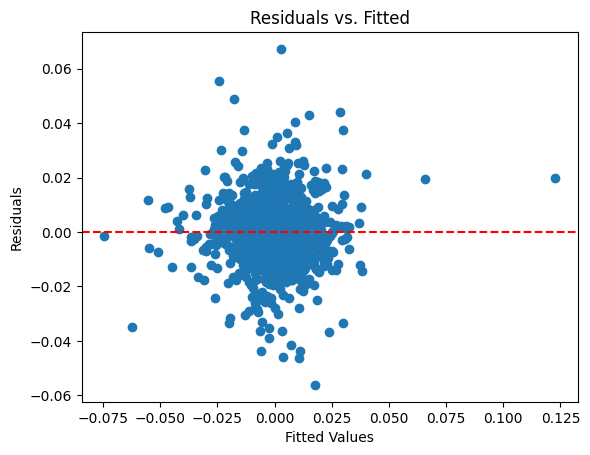

In [61]:
#Diagnostics time (residual vs. fitted, QQ plot, autocorrelation)
import matplotlib.pyplot as plt
residuals = model_nw.resid
fitted = model_nw.fittedvalues
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

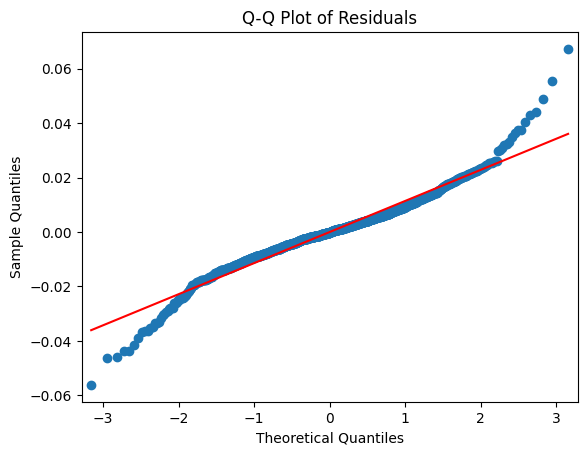

In [62]:
#q-q plot
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

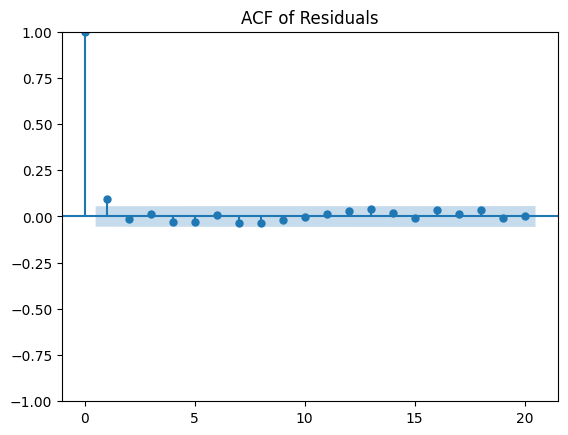

In [63]:
#ACF plot of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20)
plt.title('ACF of Residuals')
plt.show()

,const,Excess_Returns_SPY
Date,,
2021-03-30,-0.002956,1.415918
2021-03-31,-0.002701,1.423703
2021-04-01,-0.002864,1.409325
2021-04-05,-0.002161,1.453365
2021-04-06,-0.002267,1.417441


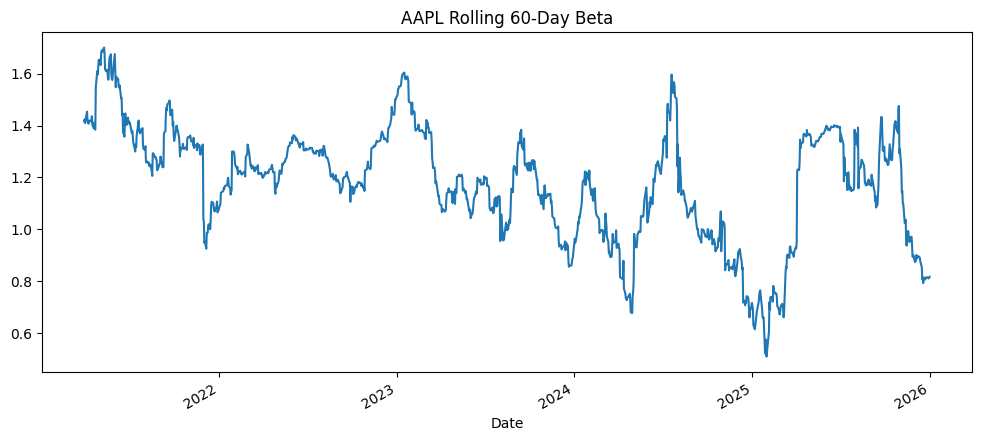

In [ ]:
# Rolling 60-day OLS beta over 2-year window with a constant term (intercept), and with Newey-West standard errors
from statsmodels.regression.rolling import RollingOLS
rolling_60 = RollingOLS(merged2['Excess_Returns_AAPL'], sm.add_constant(merged2['Excess_Returns_SPY']), window=60)
rolling_results = rolling_60.fit(cov_type='HAC', cov_kwds={'maxlags': 5})
rolling_results.params['Excess_Returns_SPY'].dropna().plot(title='AAPL Rolling 60-Day Beta', figsize=(12, 5))
rolling_results.params.dropna().head()

/var/folders/_k/6pl8b9sx41j4zs1c5nhknwcm0000gn/T/ipykernel_75034/4279351229.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_returns = merged2['Log_Returns_AAPL'].resample('Q').sum()
/var/folders/_k/6pl8b9sx41j4zs1c5nhknwcm0000gn/T/ipykernel_75034/4279351229.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_beta = rolling_results.params['Excess_Returns_SPY'].resample('Q').last()


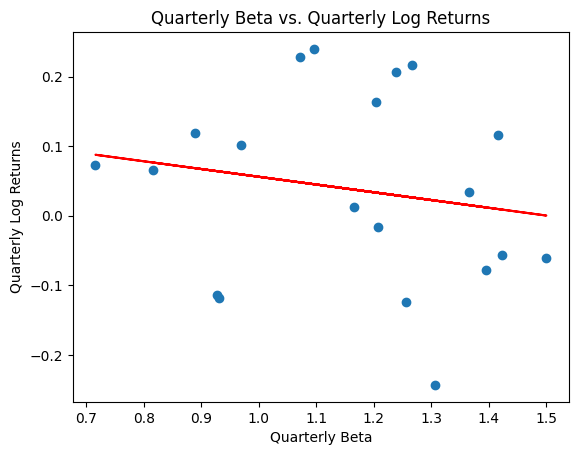

                            OLS Regression Results                            
Dep. Variable:       Log_Returns_AAPL   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.6043
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.447
Time:                        18:20:42   Log-Likelihood:                 12.105
No. Observations:                  20   AIC:                            -20.21
Df Residuals:                      18   BIC:                            -18.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1675      0

In [66]:
quarterly_returns = merged2['Log_Returns_AAPL'].resample('Q').sum()
quarterly_beta = rolling_results.params['Excess_Returns_SPY'].resample('Q').last()

# Align and drop NaN
X_quarterly = sm.add_constant(quarterly_beta.dropna())
y_quarterly = quarterly_returns.reindex(X_quarterly.index).dropna()
X_quarterly = X_quarterly.reindex(y_quarterly.index)

model_quarterly = sm.OLS(y_quarterly, X_quarterly).fit()

# Plot with regression line
plt.scatter(quarterly_beta, quarterly_returns)
plt.plot(X_quarterly['Excess_Returns_SPY'], model_quarterly.fittedvalues, color='red')
plt.title('Quarterly Beta vs. Quarterly Log Returns')
plt.xlabel('Quarterly Beta')
plt.ylabel('Quarterly Log Returns')
plt.show()

print(model_quarterly.summary())

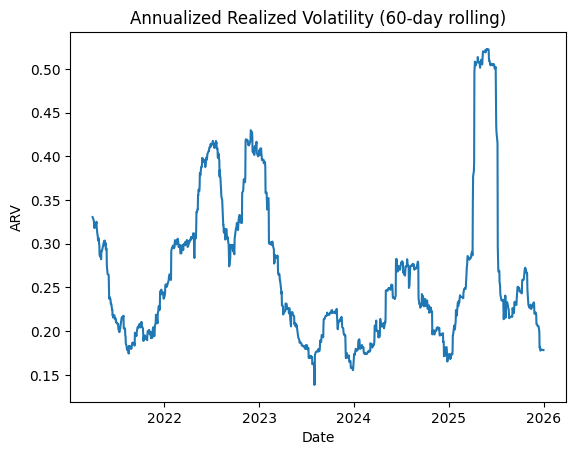

In [68]:
#Compute annualized realized volatility
ARV = merged2['Log_Returns_AAPL'].rolling(window=60).std() * np.sqrt(252)
plt.plot(ARV)
plt.title('Annualized Realized Volatility (60-day rolling)')
plt.xlabel('Date')
plt.ylabel('ARV')
plt.show()